In [1]:
# This notebook produces track objects by looping over the signal and background samples in segements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math
import glob

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *

import torch
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import radius_graph, GATConv, global_mean_pool, TransformerConv
from torch_geometric.utils import to_networkx

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import networkx as nx

%matplotlib widget

/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libcudart.so.12: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_cluster/_

In [ ]:

# Load in the signal metadata

# folder="trackreco"
# extension=""

# Get a subset of the total files to iterate over
def get_file_chunk(path, splitsize, chunk):
    
    files = sorted(glob.glob(path))
    total_files = len(files)
    
    chunk_size = math.ceil(total_files / splitsize)
    
    start = (chunk - 1) * chunk_size
    end = start + chunk_size
    
    return files[start:end]

def LoadData(path, subType, event_list, splitsize, chunk):
    
    # print("On Chunk", chunk, "/", splitsize)
    
    # Get a subset of all the files
    files = get_file_chunk(path, splitsize, chunk)
    
    # This is a list of selected events
    event_list = event_list[event_list.subType.str.contains(subType)].event_id.values
    
    data_all = []
    
    for i, f in enumerate(files):
        # if i %50 ==0:
        #     print(f"{i} /", len(files))
            
        data = pd.read_hdf(f, "data")
        data  = data[data.event_id.isin(event_list)] # filter events
        
        data["subType"] = subType
        if (subType == "0nubb"):
            data["Type"] = "0nubb"
        else:
            data["Type"] = "Bkg"
            
        data_all.append(data)
    
    data_all = pd.concat(data_all)
    num_events = len(data_all.event_id.unique())
    return num_events, data_all


def LoadPickle(path, subType, event_list, splitsize, chunk):
    
    # print("On Chunk", chunk, "/", splitsize)
    
    # Get a subset of all the files
    files = get_file_chunk(path, splitsize, chunk)
    
    event_list = event_list[event_list.subType.str.contains(subType)].event_id.values
    
    Tracks = {}
    connections = {}
    connection_counts = {}
    counter = 0
    for index, f in enumerate(files):

        # if index %50 ==0:
        #     print(f"{index} /", len(files))

        with open(f, 'rb') as pickle_file:  # Use 'rb' for reading in binary

            # Load data from file
            try:
                with open(f, 'rb') as pickle_file:
                    track_data = pickle.load(pickle_file)
                    conn_data = pickle.load(pickle_file)
                    conn_count_data = pickle.load(pickle_file)
                    
            except Exception as e:
                print(f"An unexpected error occurred while loading '{f}': {e}")
                continue
            
            # Filter during loading
            track_data = {k: v for k, v in track_data.items() if k in event_list}
            conn_data = {k: v for k, v in conn_data.items() if k in event_list}
            conn_count_data = {k: v for k, v in conn_count_data.items() if k in event_list}
            counter+=len(track_data)
            
            # Initialize or update dictionaries
            if index == 0:
                Tracks = track_data
                connections = conn_data
                connection_counts = conn_count_data
            else:
                Tracks.update(track_data)
                connections.update(conn_data)
                connection_counts.update(conn_count_data)
                
    return Tracks, connections, connection_counts

In [ ]:
# Track info to the data table
def AddTrackInfo(df, Tracks):

    rows = []
    for event_id, track_list in Tracks.items():
        for t in track_list:
            for node in t['nodes']:
                rows.append({'event_id': event_id,'id': node,'label': t['label']})
                
    tracks_df = pd.DataFrame(rows)
    df_merged = df.merge(tracks_df,how='inner',on=['event_id', 'id'])
    
    return df_merged

In [ ]:
def MinMaxScale(df, label, var_min, var_max):
    # Min-Max scaling
    df[label] = (df[label] - var_min) / (var_max - var_min)
    return df

# Function for Min-Max normalization
def normalize_group(group):
    # Avoid division by zero if a group has only one point or max == min
    if group.max() == group.min():
        return group * 0.0
    return (group - group.min()) / (group.max() - group.min())


def NormlizeDataFrame(df):

    # Normalize the columns
    xyz_mean = df[["x", "y", "z"]].mean()
    xyz_std  = df[["x", "y", "z"]].std()
    df[["x", "y", "z"]] = 0.5*(df[["x", "y", "z"]] - xyz_mean) / xyz_std

    # Apply clipping to the energy
    df['energy'] = df['energy'].clip(upper=0.4)
    df['Tortuosity'] = df['Tortuosity'].clip(upper=5)

    df = MinMaxScale(df, "energy", 0, 0.4) # 0, 0.4
    df = MinMaxScale(df, "Tortuosity", 1, 5) # 1, 4
    df = MinMaxScale(df, "angle", 0, 180) # 0, 180

    # Normalize the cumulative distance per event and track id
    df['cum_dist_norm'] = df.groupby(['event_id','trkID'])['cumulative_distance'].transform(normalize_group)
    
    return df


In [ ]:
def AddCategories(df):

  # Convert the label category to a trainable parameter
  df['label_cat'] = (
      df['label']
        .str.replace(r'^Delta\d+$', 'Delta', regex=True)
        .str.replace(r'^BremDelta\d+$', 'BremDelta', regex=True)
  )

  df['label_cat'] = df['label_cat'].astype('category')
  df['label_cat'] = df['label_cat'].cat.set_categories(['Primary', 'Delta', 'Brem', 'BremDelta'],ordered=False )

  df['SubType'] = df['subType'].astype('category')
  df['SubType'] = df['SubType'].cat.set_categories(['0nubb', 'Bi', 'Tl', 'single'],ordered=False )

  # Integer encoding for training
  df['label_id'] = df['label_cat'].cat.codes
  df['SubType_cat'] = df['SubType'].cat.codes

  label_map = {"0nubb": 1, "Bkg": 0}
  df["label"] = (df["Type"] == "0nubb").astype(int)
  
  return df

In [ ]:
def event_to_track_graph(event_df, Track):
    
    # Reset the index
    event_df = event_df.reset_index(drop=True)
    
    pos = torch.tensor(
        event_df[["x", "y", "z"]].values,
        dtype=torch.float32
    ) # N rows of [x,y,z]
    
    x = torch.tensor(event_df[["z", "energy", "Tortuosity", "cum_dist_norm", "label_id"]].values, dtype=torch.float32) # (N,5): N rows of these features
    event_id = torch.tensor(event_df["event_id"].iloc[0])
    subType = torch.tensor(event_df["SubType_cat"].iloc[0])

    # Build the track
    edge_index, edge_attr = build_track_edges_with_attr(event_df, Track, pos)
    
    y = torch.tensor([event_df["label"].iloc[0]],dtype=torch.long)
    
    return Data(x=x, pos=pos, edge_index=edge_index, edge_attr=edge_attr, y=y, event_id=event_id, subType=subType)

def build_track_edges_with_attr(event_df, tracks, pos):
    src = []
    dst = []
    edge_attr = []
    prev_dir = None  # for angle computation

    for t in tracks:
        nodes = t['nodes']
        for i in range(len(nodes) - 1):
            u = nodes[i]
            v = nodes[i + 1]

            # displacement vector
            d = pos[v] - pos[u]      # (dx, dy, dz)
            d_norm = d / 10.         # Divide by 10 to get a scale closer to ~1
            dist = torch.norm(d)     # |d|

            # direction / angle
            direction = d / (dist + 1e-8)
            
            # angle wrt previous segment
            if prev_dir is None:
                theta_norm = torch.tensor(0.0)
            else:
                cos_theta = torch.dot(prev_dir, direction)
                cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
                theta = torch.acos(cos_theta)
                theta_norm = theta / math.pi # normalize angle
            
            prev_dir = direction

            src.append(u)
            dst.append(v)
            
            # Third column is flag to tell if we added a brem connection or not
            edge_attr.append(torch.tensor([dist, 0.0], dtype=torch.float))
    
    # Map the nodes "id" to index in the dataframe
    id_map = {original_id: i for i, original_id in enumerate(event_df['id'])}
    src_indices = [id_map[id] for id in src]
    dst_indices = [id_map[id] for id in dst]
    
    # Add Brem Connections to the Primary Track
    # Uses sequential index from df, no need to remap these indices
    src_indices, dst_indices, edge_attr = AddBremConnection(event_df, tracks, src_indices, dst_indices, edge_attr)

    # edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_index = torch.tensor([src_indices, dst_indices], dtype=torch.long)
    edge_attr = torch.stack(edge_attr)

    return edge_index, edge_attr

# Need to add an edge connection between brems and the primary track
def AddBremConnection(event_df, tracks, src_indices, dst_indices, edge_attr):
    
    # Get the primary track
    for t in tracks:
        if (t["label"] == "Primary"):
            df_primary = event_df[event_df.id.isin(t["nodes"])]
            
    for t in tracks:
        
        # Skip making connections with deltas
        if ("Delta" in t["label"] or "Primary" in t["label"] ):
            continue
        
        df_track = event_df[event_df.id.isin(t["nodes"])]
        
        A = df_track[["x", "y", "z"]].to_numpy()
        B = df_primary[["x", "y", "z"]].to_numpy()

        dist = np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)

        # index of global minimum
        iA, iB = np.unravel_index(dist.argmin(), dist.shape)

        # actual DataFrame indices
        idx_A = df_track.index[iA]
        idx_B = df_primary.index[iB]
        min_distance = dist[iA, iB]
        
        # Add bi-direction to these connections and angle of zero
        src_indices.append(idx_A)
        dst_indices.append(idx_B)
        
        # Third column is flag to tell if we added a brem connection or not. Set to 1 here
        edge_attr.append(torch.tensor([min_distance, 1.0], dtype=torch.float))

        src_indices.append(idx_A)
        dst_indices.append(idx_B)
        edge_attr.append(torch.tensor([min_distance, 1.0], dtype=torch.float))
        
    
    return src_indices, dst_indices, edge_attr



In [ ]:
def build_graph_dataset(df, Tracks):
    graphs = []

    for ev_id in df.event_id.unique():
        graphs.append(event_to_track_graph(df[df.event_id == ev_id], Tracks[ev_id])) # Track connections
    return graphs



In [ ]:
basepath = "/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/"

listin=f"../eventlists/ATPC_1bar_5percent_highstats.csv"
event_list = pd.read_csv(listin);


def GetGraphs(event_list, mode, splitsize):
    print("Getting Graphs for:", mode)
    
    tot_events = 0
    
    if mode == "Bi" or mode == "Tl":
        basepath = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_{mode}_ion/1bar/5percent/"
    else:
        basepath = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_{mode}/1bar/5percent/"
        
    
    for i in np.arange (1,splitsize+1,1):
        
        # if i <=6:
        #     continue
        
        num_events, data     = LoadData(f"{basepath}/reco/*.h5", mode,  event_list, splitsize, i)
        Tracks,  connections,  connection_counts  = LoadPickle(f"{basepath}/pkl/*.pkl", mode,  event_list, splitsize, i)
        
        tot_events+=num_events
            
        print("Adding Track Info for chunk:", i)
        df_merged = AddTrackInfo(data, Tracks)
        df_merged = NormlizeDataFrame(df_merged)
        df_merged = AddCategories(df_merged)
        print("Building Graph for chunk:", i)
        graphs = build_graph_dataset(df_merged, Tracks)
        torch.save(graphs, f'../GNN_files/ATPC_GNN_{mode}_chunk_{i}.pt')
        # break
        
    print("tot_events saved:", tot_events)

# GetGraphs(event_list, "single", 5 )
# GetGraphs(event_list, "Bi",     5 )
# GetGraphs(event_list, "Tl",     5 )
# GetGraphs(event_list, "0nubb",  25)

In [7]:
# Load in the graphs

def LoadGraphs():
    
    all_graphs = []
    
    files = sorted(glob.glob('../GNN_files/*chunk*.pt'))
    for f in files:
        print(f)
        graph = torch.load(f)
        all_graphs.extend(graph)
    
    return all_graphs

all_graphs = LoadGraphs()


../GNN_files/ATPC_GNN_0nubb_chunk_1.pt
../GNN_files/ATPC_GNN_0nubb_chunk_10.pt
../GNN_files/ATPC_GNN_0nubb_chunk_11.pt
../GNN_files/ATPC_GNN_0nubb_chunk_12.pt
../GNN_files/ATPC_GNN_0nubb_chunk_13.pt
../GNN_files/ATPC_GNN_0nubb_chunk_14.pt
../GNN_files/ATPC_GNN_0nubb_chunk_15.pt
../GNN_files/ATPC_GNN_0nubb_chunk_16.pt
../GNN_files/ATPC_GNN_0nubb_chunk_17.pt
../GNN_files/ATPC_GNN_0nubb_chunk_18.pt
../GNN_files/ATPC_GNN_0nubb_chunk_19.pt
../GNN_files/ATPC_GNN_0nubb_chunk_2.pt
../GNN_files/ATPC_GNN_0nubb_chunk_20.pt
../GNN_files/ATPC_GNN_0nubb_chunk_21.pt
../GNN_files/ATPC_GNN_0nubb_chunk_22.pt
../GNN_files/ATPC_GNN_0nubb_chunk_23.pt
../GNN_files/ATPC_GNN_0nubb_chunk_24.pt
../GNN_files/ATPC_GNN_0nubb_chunk_25.pt
../GNN_files/ATPC_GNN_0nubb_chunk_3.pt
../GNN_files/ATPC_GNN_0nubb_chunk_4.pt
../GNN_files/ATPC_GNN_0nubb_chunk_5.pt
../GNN_files/ATPC_GNN_0nubb_chunk_6.pt
../GNN_files/ATPC_GNN_0nubb_chunk_7.pt
../GNN_files/ATPC_GNN_0nubb_chunk_8.pt
../GNN_files/ATPC_GNN_0nubb_chunk_9.pt
../GNN_fi

In [8]:
for d in all_graphs:
    d.y = d.y.long()

In [9]:
print(f"Total graphs loaded: {len(all_graphs)}")
print(f"Type of first object: {type(all_graphs[0])}")

Total graphs loaded: 1008334
Type of first object: <class 'torch_geometric.data.data.Data'>


In [10]:
labels = [d.y.item() for d in all_graphs]
subTypes = [d.subType.item() for d in all_graphs]


class_names = ['0nubb', 'Bi', 'Tl', 'single']
counts = pd.Series(subTypes).value_counts()
counts.index = counts.index.map(lambda x: class_names[int(x)])
print(counts)

Num_Signal = counts[0]
Num_Bkg    = counts[1:].sum()

print("")
print("Number Signal:", Num_Signal)
print("Number Background:", Num_Bkg)

scale_factor_bkg = Num_Signal/Num_Bkg

0nubb     752591
Bi         86320
single     85135
Tl         84288
Name: count, dtype: int64

Number Signal: 752591
Number Background: 255743


In [11]:
temp_graphs, test_graphs, temp_labels, test_labels  = train_test_split(all_graphs, labels, test_size=0.10, stratify=labels, random_state=42)
train_graphs, val_graphs, train_labels, val_labels  = train_test_split(temp_graphs, temp_labels, test_size=2/9,  stratify=temp_labels, random_state=42)

train_loader = DataLoader(train_graphs,batch_size=1024, shuffle=True,  num_workers=10, pin_memory=True)
val_loader   = DataLoader(val_graphs,  batch_size=1024, shuffle=False, num_workers=10, pin_memory=True)
test_loader  = DataLoader(test_graphs, batch_size=1024, shuffle=False, num_workers=10, pin_memory=True)

In [2]:
# Define the GNN
class GATNet(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, heads=4):
        super().__init__()

        self.conv1 = GATConv(num_node_features, hidden_channels, heads=heads, concat=False) # concat False keeps hidden_channels fixed
        self.conv2 = GATConv(hidden_channels,   hidden_channels, heads=heads, concat=False)
        self.conv3 = GATConv(hidden_channels,   hidden_channels, heads=1,     concat=False)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class GATNetEdge(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, edge_dim, heads=4):
        super().__init__()

        self.conv1 = GATConv( num_node_features, hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv2 = GATConv( hidden_channels,   hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv3 = GATConv( hidden_channels,   hidden_channels, heads=1,     concat=False, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class EventTransformerConv(torch.nn.Module):
    def __init__(self, hidden_channels, num_classes, num_node_features, edge_dim):
        super().__init__()
        self.conv1 = TransformerConv(num_node_features, hidden_channels, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.conv3 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

In [3]:
# Check for CUDA (NVIDIA) or MPS (Apple)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

scale_factor_bkg = None  # Initialize it globally or at the top
df_merged = pd.DataFrame()

NVIDIA GeForce RTX 2060
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Using device: cuda


In [ ]:
def accuracy_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


# Define your ML models here
# model = GATNetEdge(hidden_channels=64, num_classes=2, edge_dim=2, num_node_features = 5).to(device) # GAT + Edge Features
model = EventTransformerConv(hidden_channels=64, num_classes=2, num_node_features=5, edge_dim=2).to(device) # Transformer model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# if we loading directly from file, then this wont be set, use last value 
if (scale_factor_bkg == None):
    scale_factor_bkg = 0.3520650813516896
    
print("scale_factor_bkg is ", scale_factor_bkg)
 
criterion = nn.CrossEntropyLoss(weight=torch.tensor([scale_factor_bkg, 1.0])).to(device) # [background, signal]

train_loss_hist = []
val_loss_hist = []
val_acc_hist = []
best_val_loss=1e20
history_list = []

for epoch in range(25):

    # -------- training --------
    # Put the model in training mode, gradients will be computed
    model.train() 
    train_loss = 0.0 # Sum the loss over all batches, then average it

    # Loop over training batches
    for data in train_loader:
        
        data = data.to(device) # Move the whole graph batch to GPU
        
        # print("x:", data.x.shape)
        # print("edge_index:", data.edge_index.shape)
        # print("edge_attr:", data.edge_attr.shape)
        
        optimizer.zero_grad()            # Clear old features
        logits = model(data)             # Data flows through the network, the output is called logits (raw scores not probabilities) -- forward pass
        loss = criterion(logits, data.y) # Compares the predictions (logits) with the true labels (yb)
        loss.backward()                  # Computes the gradients of the loss (stored in param.grad for every model param)
        optimizer.step()                 # Uses the gradients to update the weights. Depends on the optimizer e.g. SGD, Adam etc -- this is the learning step

        train_loss += loss.item() * data.num_graphs # Accumulates the total loss. loss.item() returns the loss for this batch. So multiply by batch size data.num_graphs 

    train_loss /= len(train_loader.dataset) # Average the training loss over the total dataset
    train_loss_hist.append(train_loss)

    # -------- validation --------
    model.eval() # Disables dropout, freezes batchnorm statistics, ensures deterministic behaviour
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad(): # Disables gradient tracking (saves memory, speeds up evalulation, prevents accidental backpropagation)
        for data in val_loader:
            data = data.to(device) # Move the whole graph batch to GPU
            
            logits = model(data)
            loss = criterion(logits, data.y)

            val_loss += loss.item() * data.num_graphs
            val_acc += accuracy_from_logits(logits, data.y) * data.num_graphs # Converts logits -> predicted class, compares with y

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )
    
    # Saving the model 
    checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': val_loss,
    }

    if val_loss < best_val_loss:
        torch.save(checkpoint, '../GNN_files/graph_transformer_v1.pt')
        print("Model improved! Saving...")
    
    # Saving the information from the training
    metrics = {
        'epoch': epoch,
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'val_acc': val_acc
    }
    history_list.append(metrics)

# Save the history of the training
history_df = pd.DataFrame(history_list)
history_df.to_csv('../GNN_files/GNN_train_history.csv', index=False)

model.eval()
test_loss = 0.0
test_acc = 0.0

with torch.no_grad():
    for data in test_loader:
        
        data = data.to(device) # Move the whole graph batch to GPU
        
        logits = model(data)
        loss = criterion(logits, data.y)

        test_loss += loss.item() * data.num_graphs
        test_acc  += accuracy_from_logits(logits, data.y) * data.num_graphs

test_loss /= len(test_loader.dataset)
test_acc  /= len(test_loader.dataset)

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.3f}")

In [17]:
# Load in the best model during training and the training history
# Define your ML models here
# model = GATNetEdge(hidden_channels=64, num_classes=2, edge_dim=2, num_node_features = 5).to(device) # GAT + Edge Features
model = EventTransformerConv(hidden_channels=64, num_classes=2, num_node_features=5, edge_dim=2).to(device) # Transformer model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# if we loading directly from file, then this wont be set, use last value 
if (scale_factor_bkg == None):
    scale_factor_bkg = 0.3520650813516896
    
print("scale_factor_bkg is ", scale_factor_bkg)
 
criterion = nn.CrossEntropyLoss(weight=torch.tensor([scale_factor_bkg, 1.0])).to(device) # [background, signal]

checkpoint = torch.load('../GNN_files/graph_transformer_v1.pt', map_location=device)

# 4. Restore the states
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


history_df = pd.read_csv("../GNN_files/GNN_train_history.csv")
display(history_df)

scale_factor_bkg is  2.942762851769159


,epoch,train_loss,val_loss,val_acc
0,0,0.261630,0.220427,0.817754
1,1,0.211786,0.204943,0.849132
2,2,0.200967,0.202090,0.859680
3,3,0.195144,0.193218,0.861435
4,4,0.191145,0.187922,0.855851
5,5,0.188408,0.186022,0.853848
6,6,0.186151,0.183260,0.863428
7,7,0.184037,0.191096,0.840554
8,8,0.182813,0.183214,0.873182
9,9,0.180797,0.178616,0.870157


In [13]:
def compute_roc(model, loader, device):
    model.eval()
    y_true, y_score, p_signal_bkg, p_signal_sig, event_ids, subTypes = [], [], [], [], [], []

    with torch.no_grad():
        # Loops over in batches specified in dataloader, returns array of length of the batch size. 
        for data in loader:
            data = data.to(device)
            logits = model(data)
            probs = torch.softmax(logits, dim=1) # List of length batch size, 2 rows, [p_bkg, p_sig]
            
            p_signal = probs[:, 1].cpu() # Get the signal column probs
            y        = data.y.cpu()      # Get the y labels
            
            y_score.append(p_signal)
            y_true.append(y)
            subTypes.append(data.subType.cpu())
            event_ids.append(data.event_id.cpu())
            
            # Append scores depending on true classification
            p_signal_bkg.append(p_signal[y.numpy() == 0])
            p_signal_sig.append(p_signal[y.numpy() == 1])

    y_true  = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()
    event_ids = torch.cat(event_ids).numpy()
    subTypes = torch.cat(subTypes).numpy()
    
    p_signal_bkg = np.concatenate(p_signal_bkg)
    p_signal_sig = np.concatenate(p_signal_sig)
    
    df_scores = pd.DataFrame({"event_id":event_ids, "y_score":y_score, "y_true":y_true, "subTypes" : subTypes})
    
    mapping = {i: name for i, name in enumerate(class_names)}
    df_scores['subTypes'] = df_scores['subTypes'].map(mapping)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    
    return fpr, tpr, auc(fpr, tpr), df_scores

fpr_tr,   tpr_tr, auc_tr,   df_scores_tr  = compute_roc(model, train_loader, device)
fpr_va,   tpr_va, auc_va,   df_scores_va = compute_roc(model, val_loader,   device)
fpr_tst, tpr_tst, auc_tst,  df_scores_tst = compute_roc(model, test_loader,  device)
df_scores_all = pd.concat([df_scores_tr, df_scores_va, df_scores_tst])
display(df_scores_all)

,event_id,y_score,y_true,subTypes
0,39900529,0.024039,0,single
1,2320981,0.941443,1,0nubb
2,1300319,0.904475,1,0nubb
3,1333682,0.983698,1,0nubb
4,146181236,0.634696,0,single
...,...,...,...,...
100829,94710000226,0.075613,0,Bi
100830,4368648,0.341287,0,single
100831,1225095,0.927417,1,0nubb
100832,1059985,0.929142,1,0nubb


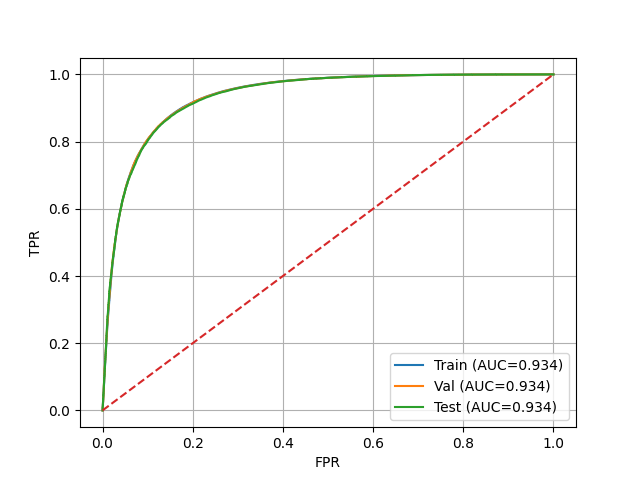

Val AUC: 0.934 


In [14]:
plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_va, tpr_va, label=f"Val (AUC={auc_va:.3f})")
plt.plot(fpr_tst, tpr_tst, label=f"Test (AUC={auc_va:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()
print(f"Val AUC: {auc_va:.3f} ")


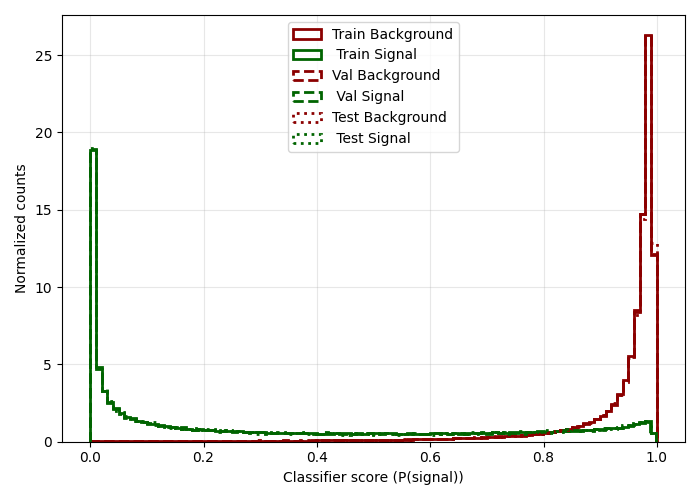

0.28319836711073226 0.04523572564646672


In [15]:
plt.figure(figsize=(7,5))

bins = 100


plt.hist(df_scores_tr[df_scores_tr.y_true == 1].y_score,bins=bins,density=True,histtype='step',linewidth=2,label='Train Background', linestyle = "-", color = "darkred")
plt.hist(df_scores_tr[df_scores_tr.y_true == 0].y_score,bins=bins,density=True,histtype='step',linewidth=2,label=' Train Signal', linestyle = "-", color = "darkgreen")

plt.hist(df_scores_va[df_scores_va.y_true == 1].y_score,bins=bins,density=True,histtype='step',linewidth=2,label='Val Background', linestyle = "--", color = "darkred")
plt.hist(df_scores_va[df_scores_va.y_true == 0].y_score,bins=bins,density=True,histtype='step',linewidth=2,label=' Val Signal', linestyle = "--", color = "darkgreen")

plt.hist(df_scores_tst[df_scores_tst.y_true == 1].y_score,bins=bins,density=True,histtype='step',linewidth=2,label='Test Background', linestyle = ":", color = "darkred")
plt.hist(df_scores_tst[df_scores_tst.y_true == 0].y_score,bins=bins,density=True,histtype='step',linewidth=2,label=' Test Signal', linestyle = ":", color = "darkgreen")


plt.xlabel("Classifier score (P(signal))")
plt.ylabel("Normalized counts")
plt.legend()
plt.grid(alpha=0.3)

# plt.semilogy()
plt.tight_layout()
plt.show()

cut = 0.6
signal_eff = len(df_scores_all[ (df_scores_all.y_true == 0) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 0)])
bkg_rej = 1 - len(df_scores_all[ (df_scores_all.y_true == 1) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 1)])
print(signal_eff, bkg_rej)

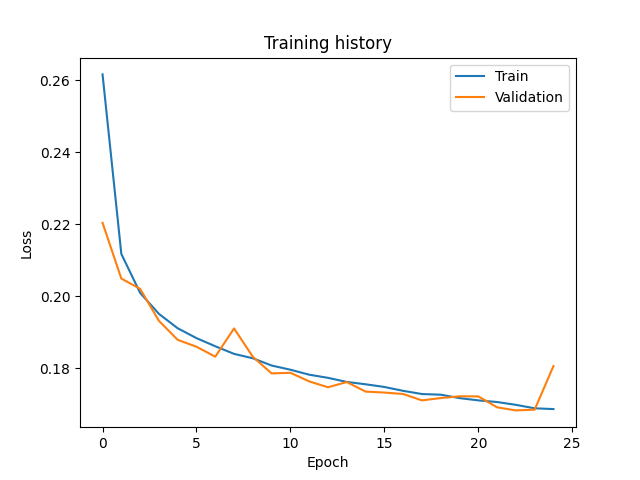

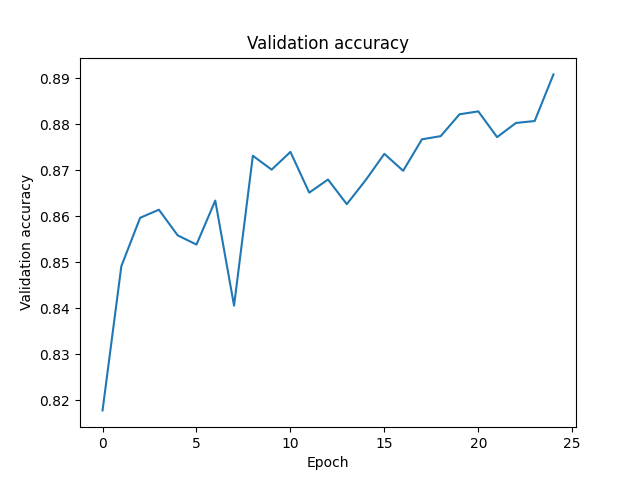

In [19]:
plt.figure()
plt.plot(history_df.train_loss, label='Train')
plt.plot(history_df.val_loss, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training history')
plt.show()

plt.figure()
plt.plot(history_df.val_acc)
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy')
plt.show()

Cut =  0.965
Signal Eff:   0.57
Bkg Eff, Bkg Rej, Bkg Rej Fact
Tl ERej:      0.011 0.989 89.01
Bi ERej:      0.040 0.960 24.73
single ERej:  0.057 0.943 17.49


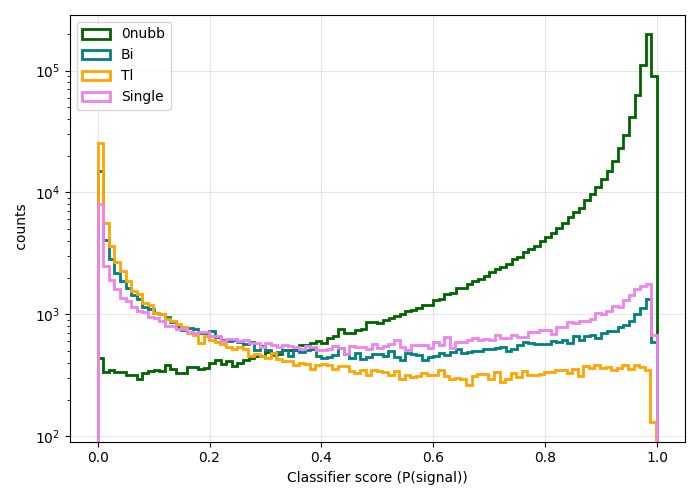

In [26]:
def CalcEfficiency(df, label, cut):
    num = len(df[ (df.subTypes == label) & (df.y_score > cut)])
    den = len(df[ (df.subTypes == label)])
    return num/den

cut = 0.965

print("Cut = ", cut)
print(f"Signal Eff:   {CalcEfficiency(df_scores_all, '0nubb', cut):.2f}")

print("Bkg Eff, Bkg Rej, Bkg Rej Fact")
tl_eff = CalcEfficiency(df_scores_all, "Tl", cut)
print(f"Tl ERej:      {tl_eff:.3f} {1-tl_eff:.3f} {1/tl_eff:.2f}")

bi_eff = CalcEfficiency(df_scores_all, "Bi", cut)
print(f"Bi ERej:      {bi_eff:.3f} {1-bi_eff:.3f} {1/bi_eff:.2f}")

s_eff = CalcEfficiency(df_scores_all, "single", cut)
print(f"single ERej:  {s_eff:.3f} {1-s_eff:.3f} {1/s_eff:.2f}")

plt.figure(figsize=(7,5))

bins = 100

plt.hist(df_scores_all[ (df_scores_all.subTypes == "0nubb")].y_score,  bins=bins, density=False, histtype='step', linewidth=2, label='0nubb',  color = "darkgreen");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Bi")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Bi',     color = "Teal");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Tl")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Tl',     color = "Orange");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "single")].y_score, bins=bins, density=False, histtype='step', linewidth=2, label='Single', color = "violet");


plt.xlabel("Classifier score (P(signal))")
plt.ylabel(" counts")
plt.legend()
plt.grid(alpha=0.3)

plt.semilogy()
plt.tight_layout()
plt.show()